# Mechanistic exploration Payoff

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from Classes.bar import Bar
from Config.config import PATHS
from Utils.interaction import Episode
from Classes.cognitive_model_agents import PayoffM2

### Favorable transition

Actions: [[1, 1, 0], [1, 0, 1]]
Decisions: [1, 1, 0]
agent.decisions: [], player_decision: 1

Decisions: [1, 0, 1]
Agent's payoff: 1
agent.decisions: [1], player_decision: 1


<Axes: xlabel='Preference (%)'>

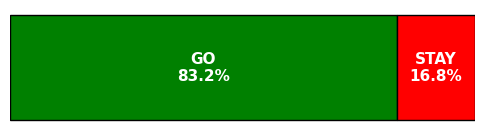

In [2]:
free_paramters = {
    'inverse_temperature': 16,
    'learning_rate':0.1,
}
fixed_parameters = {
    'num_agents':3,
    'threshold':0.7
}
bar = Bar(**fixed_parameters)

agent = PayoffM2(
    free_parameters=free_paramters,
    fixed_parameters=fixed_parameters,
)
agent.number = 0
payoffs = []
attendances = []
probability_go = []
probability_no_go = []
actions = [
# High threshold
    [1, 1],
    [1, 0],
    [0, 1],
]
actions = np.array(actions).T.tolist()
print(f"Actions: {actions}")

decisions = actions[0]
print(f"Decisions: {decisions}")
# Update bar with decisions
attendance, scores = bar.step(decisions[::-1])
player_decision = decisions[0]
# Find payoff
payoff = agent.payoff(player_decision, decisions)
payoffs.append(payoff)
# Find attendances
print(f"agent.decisions: {agent.decisions}, player_decision: {player_decision}")
average_go = np.mean(agent.decisions + [player_decision])
attendances.append(average_go)
# Update agents with decisions
agent.update(payoff, decisions)
agent.prev_state_ = decisions

print('')

decisions = actions[1]
print(f"Decisions: {decisions}")
# Update bar with decisions
attendance, scores = bar.step(decisions[::-1])
player_decision = decisions[0]
# Find payoff
payoff = agent.payoff(player_decision, decisions)
print(f"Agent's payoff: {payoff}")
payoffs.append(payoff)
# Find attendances
print(f"agent.decisions: {agent.decisions}, player_decision: {player_decision}")
average_go = np.mean(agent.decisions + [player_decision])
attendances.append(average_go)
# Update agents with decisions
agent.update(payoff, decisions)

agent.prev_state_ = actions[0]
agent.plot_action_probabilities()


### Unfavorable transition

Actions: [[1, 1, 0], [1, 1, 1]]
Decisions: [1, 1, 0]
agent.decisions: [], player_decision: 1

Decisions: [1, 1, 1]
Agent's payoff: -1
agent.decisions: [1], player_decision: 1


<Axes: xlabel='Preference (%)'>

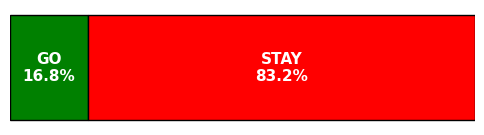

In [3]:
free_paramters = {
    'inverse_temperature': 16,
    'learning_rate':0.1,
}
fixed_parameters = {
    'num_agents':3,
    'threshold':0.7
}
bar = Bar(**fixed_parameters)

agent = PayoffM2(
    free_parameters=free_paramters,
    fixed_parameters=fixed_parameters,
)
agent.number = 0
payoffs = []
attendances = []
probability_go = []
probability_no_go = []
actions = [
# High threshold
    [1, 1],
    [1, 1],
    [0, 1],
]
actions = np.array(actions).T.tolist()
print(f"Actions: {actions}")

decisions = actions[0]
print(f"Decisions: {decisions}")
# Update bar with decisions
attendance, scores = bar.step(decisions[::-1])
player_decision = decisions[0]
# Find payoff
payoff = agent.payoff(player_decision, decisions)
payoffs.append(payoff)
# Find attendances
print(f"agent.decisions: {agent.decisions}, player_decision: {player_decision}")
average_go = np.mean(agent.decisions + [player_decision])
attendances.append(average_go)
# Update agents with decisions
agent.update(payoff, decisions)
agent.prev_state_ = decisions

print('')

decisions = actions[1]
print(f"Decisions: {decisions}")
# Update bar with decisions
attendance, scores = bar.step(decisions[::-1])
player_decision = decisions[0]
# Find payoff
payoff = agent.payoff(player_decision, decisions)
print(f"Agent's payoff: {payoff}")
payoffs.append(payoff)
# Find attendances
print(f"agent.decisions: {agent.decisions}, player_decision: {player_decision}")
average_go = np.mean(agent.decisions + [player_decision])
attendances.append(average_go)
# Update agents with decisions
agent.update(payoff, decisions)

agent.prev_state_ = actions[0]
agent.plot_action_probabilities()

### Playout with probabilities

In [4]:
free_paramters = {
    'inverse_temperature': 16,
    'learning_rate':0.1,
}
fixed_parameters = {
    'num_agents':3,
    'threshold':0.7
}

In [47]:
bar = Bar(**fixed_parameters)
agents = [
    PayoffM2(
        free_parameters=free_paramters,
        fixed_parameters=fixed_parameters,
    ) for _ in range(fixed_parameters['num_agents'])
]
for i, agent in enumerate(agents):
    agent.number = i
    
episode = Episode(
    bar, agents, 'Payoff', num_rounds=20
)

In [50]:
episode.run()
df = episode.to_pandas()
df['attendance'] = df['attendance'].apply(lambda x: sum(x))

<Axes: xlabel='round', ylabel='attendance'>

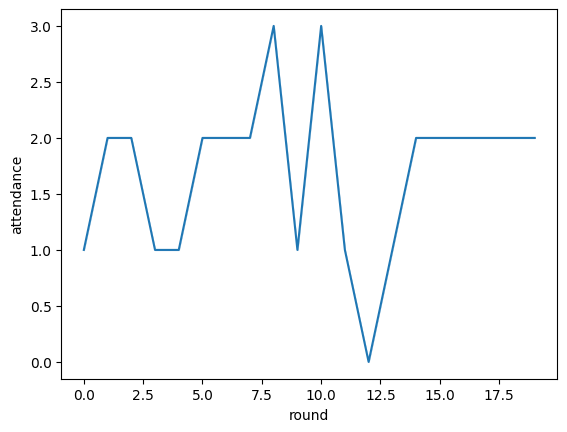

In [51]:
sns.lineplot(
    x='round', y='attendance',
    data=df
)

<Axes: xlabel='Preference (%)'>

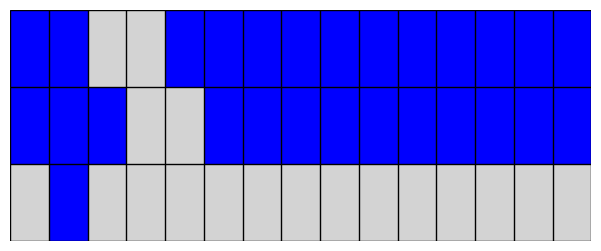

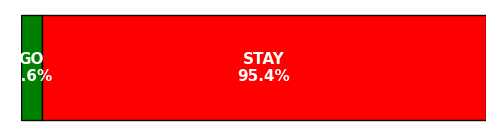

In [57]:
bar.render()
agents[0].plot_action_probabilities()

Text(-0.1, 0.86, 'Pl1')

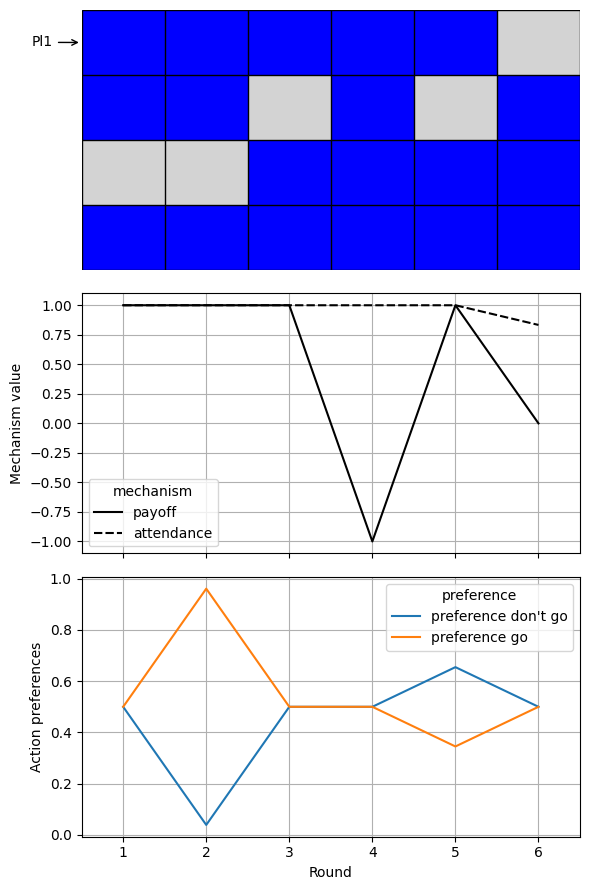

In [ ]:
fig, ax = plt.subplots(
    3, 1, 
    figsize=(6,9), 
    tight_layout=True,
)

bar.render(ax=ax[0], num_rounds=num_rounds)

n1, n2 = len(payoffs), len(attendances)
df_values = pd.DataFrame({
    'round': list(range(1, n1 + 1)) + list(range(1, n2 + 1)),
    'value': payoffs + attendances,
    'mechanism': ["payoff"]*n1  + ["attendance"]*n2
})

n1, n2 = len(probability_no_go), len(probability_go)
df_preferences = pd.DataFrame({
    'round': list(range(1, n1 + 1)) + list(range(1, n2 + 1)),
    'value': probability_no_go + probability_go,
    'preference': ["preference don't go"]*n1 + ["preference go"]*n2
})


sns.lineplot(
    x="round", y="value", style="mechanism",
    style_order=["payoff", "attendance"],
    data=df_values, ax=ax[1],
    color='black'
)
ax[1].grid()
ax[1].set_ylabel('Mechanism value')
ax[1].set_xlim([0.5, num_rounds + 0.5])
ax[1].set_xlabel('')
ax[1].set_xticks(range(1, num_rounds + 1)) 
ax[1].set_xticklabels([])

sns.lineplot(
    x="round", y="value", hue="preference",
    hue_order=["preference don't go", "preference go"],
    data=df_preferences, ax=ax[2],
    color='black'
)
ax[2].set_ylabel('Action preferences')

ax[2].set_xlabel('Round')
ax[2].set_xlim([0.5, num_rounds + 0.5])
ax[2].set_xticks(range(1, num_rounds + 1)) 
ax[2].set_xticklabels(range(1, num_rounds + 1))
ax[2].grid()

ax[0].annotate(
    'Pl1',
    xy=(0, 0.875), xycoords='axes fraction',
    xytext=(-0.1, 0.86), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='->'),
)

In [ ]:
import sys
sys.path.append('../src')

import re
import ast
import pandas as pd

from Config.config import PATHS
from Utils.utils import GetMeasurements
from Utils.interaction import Performer
from Utils.indices import AlternationIndex
from Classes.cognitive_model_agents import *

In [ ]:
path_to_data = PATHS['simulated_data'] / 'optimal_parameters.csv'
optimal_parameters = pd.read_csv(path_to_data)

In [ ]:
def parse_params(s):
    if not isinstance(s, str):
        return s
    # Replace np.float64(x) and np.int64(x) with x
    s = re.sub(r'np\.float64\(([^)]+)\)', r'\1', s)
    s = re.sub(r'np\.int64\(([^)]+)\)', r'\1', s)
    return ast.literal_eval(s)

In [ ]:
MODEL_BY_NAME = {m.name(): m for m in MODELS}

fixed_parameters = {
    'num_agents': 2,
    'threshold': 0.5,
}
simulation_parameters = {
    'num_rounds': 10,
    'num_episodes': 10,
    'verbose': False
}

df_list =[] 
for idx, row in optimal_parameters.iterrows():
    if row['model'].startswith('Priors'):
        continue
    model_class = MODEL_BY_NAME[row['model']]
    free_parameters = parse_params(row['params'])
    df = Performer.sim(
        agent_class=model_class,
        fixed_parameters=fixed_parameters,
        free_parameters=free_parameters,
        simulation_parameters=simulation_parameters
    )
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)
df.head(2)


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

/Users/edgarjoseandradelotero/GitHub/Cognitive_Models_El_Farol_Bar_Problem/Notebooks/../src/Utils/interaction.py:920: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  'x_label':'$\mu$',


KeyError: 'forget'

In [ ]:
gm = GetMeasurements(
    data=df, 
    measures=[
        'efficiency', 'inequality',
        'bounded_efficiency', 
        'entropy', 'conditional_entropy', 
        'conditional_entropy_2nd_order', 'min_entropy'
    ],
    normalize=True,
)
data = gm.get_measurements()
index_gen = AlternationIndex.from_file(priority='mlp')
data['inequality'] = index_gen(data)
data.head(2)

Exception: Error: No column data found. Should be one of "id_sim", "room", or "group".
Columns found: Index(['round', 'attendance', 'id_player', 'decision', 'score'], dtype='str')